In [14]:
import wandb
import pandas as pd

api = wandb.Api()
entity, project = "guilain-leduc", "RL_blockchain"


Experiment runed with

```bash
#!/bin/bash

pas=0.1
export LC_NUMERIC=C

for a in $(seq 0 "$pas" 1); do
    b=$(awk -v a="$a" 'BEGIN { print 1-a }')
    echo "$a $b"

  /home/gleduc/rl-blockchain/src/rl_blockchain/scripts/run.py --voting-nodes 0 --n-nodes 25 --wandb-entity guilain-leduc --logging-prefix train_b_1.5_w_$a ppo --update-params 2 --next-edge-type 1 --eval-episodes 100 --gini-reward-mode differential_shaped --gini-shaping-beta 1.5 --reward-weights $a $b -- train --learning-rate 0.0003 0.00005 --num-epochs 400 --num-steps 2000 --batch-size 64 --num-envs 6 --micro-batch-size 16 --entropy-coef 0.01 0 0 0
```

In [15]:
used_runs = ['ylzql11r', '5vash3xr', 'xr3fufwl', 'cdnff4ov', 'e93i5kaw', 'zq9l8dic', 'j4rg0jyq', '0o2ajcrb', 'aepj6f8f',
             'r8bcco7s', 'wezov2hm']

In [16]:
runs = [
    api.run(f"{entity}/{project}/{run_id}")
    for run_id in used_runs
]

In [20]:
metrics_per_run = []

for run in runs:
    history = run.history(samples=1)
    metrics_per_run.append(set(history.columns))

common_metrics = set.intersection(*metrics_per_run)

# Retire les colonnes internes W&B
common_metrics = sorted(
    metric for metric in common_metrics
    if not metric.startswith("_")
)

common_metrics

['coef.clip_ratio',
 'coef.entropy_coef',
 'coef.value_coef',
 'decomp.adv_std_distance',
 'decomp.adv_std_gini',
 'decomp.adv_std_ratio_gini_over_distance',
 'decomp.beta_star',
 'decomp.std_level',
 'decomp.std_shaping',
 'decomp.value_mean_distance',
 'decomp.value_mean_gini',
 'env.avg_rewards',
 'env.distance',
 'env.distance_reward',
 'env.fairness_reward',
 'env.gini',
 'env.gini_reward',
 'env.nb_sequences_done',
 'env.nb_validators',
 'env.nb_validators_std',
 'env.reward_mean_per_episode',
 'env.weighted_original_reward',
 'env.weighted_reward',
 'epoch',
 'eval_gap_greedy_stochastic.avg_returns_episode',
 'eval_gap_greedy_stochastic.avg_rewards',
 'eval_gap_greedy_stochastic.distance',
 'eval_gap_greedy_stochastic.distance_reward',
 'eval_gap_greedy_stochastic.fairness_reward',
 'eval_gap_greedy_stochastic.fairness_reward_episodic_sum',
 'eval_gap_greedy_stochastic.gini',
 'eval_gap_greedy_stochastic.gini_reward',
 'eval_gap_greedy_stochastic.nb_sequences_done',
 'eval_gap_g

In [27]:
import pandas as pd

metric = "decomp.beta_star"

results = []

for run in runs:
    df = pd.DataFrame(
        run.scan_history(keys=["_step", metric])
    )

    # Supprime les points où la métrique n'a pas été mesurée
    values = df[metric].dropna()

    # Dernier tiers
    n = len(values)
    last_third = values.iloc[2 * n // 3:]

    results.append({
        "run_id": run.id,
        "run_name": run.name,
        "n_measurements": n,
        "reward_weights": run.config.get("reward_weights"),
        "last_third_mean": last_third.mean(),
    })

result_df = pd.DataFrame(results)

result_df

,run_id,run_name,n_measurements,reward_weights,last_third_mean
0,ylzql11r,train_b_1.5_w_0.0_134,400,"[0, 1]",0.339289
1,5vash3xr,train_b_1.5_w_0.1_135,400,"[0.1, 0.9]",0.438065
2,xr3fufwl,train_b_1.5_w_0.2_136,400,"[0.2, 0.8]",0.638835
3,cdnff4ov,train_b_1.5_w_0.3_137,400,"[0.3, 0.7]",1.190040
4,e93i5kaw,train_b_1.5_w_0.4_138,400,"[0.4, 0.6]",1.135163
5,zq9l8dic,train_b_1.5_w_0.5_139,400,"[0.5, 0.5]",2.380695
6,j4rg0jyq,train_b_1.5_w_0.6_140,400,"[0.6, 0.4]",1.400825
7,0o2ajcrb,train_b_1.5_w_0.7_141,400,"[0.7, 0.3]",2.250263
8,aepj6f8f,train_b_1.5_w_0.8_142,400,"[0.8, 0.2]",2.457506
9,r8bcco7s,train_b_1.5_w_0.9_143,400,"[0.9, 0.1]",2.383082


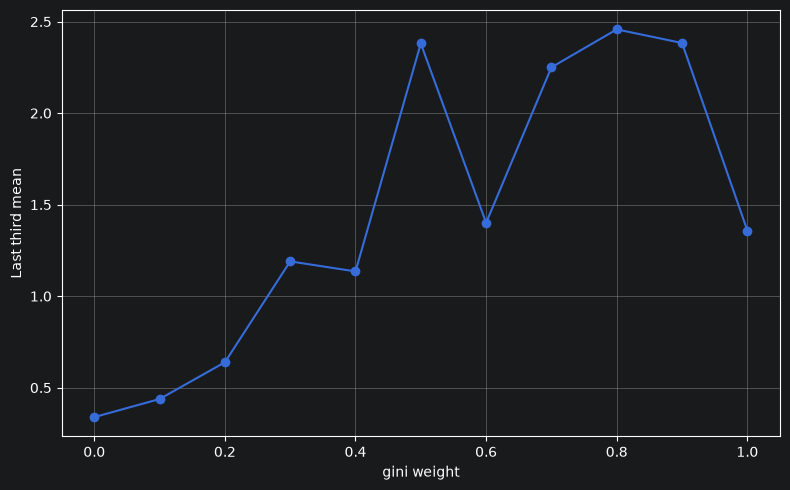

In [32]:
import matplotlib.pyplot as plt

result_df["gini_weight"] = result_df["reward_weights"].str[0]
df_plot = result_df.sort_values("gini_weight")

plt.figure(figsize=(8, 5))
plt.plot(
    df_plot["gini_weight"],
    df_plot["last_third_mean"],
    marker="o",
)

plt.xlabel("gini weight")
plt.ylabel("Last third mean")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
run = api.run(f"{entity}/{project}/{used_runs[0]}")

run.config

{'env': 'blockenv',
 'algo': 'ppo',
 'mode': 'train',
 'seed': 0,
 'gamma': 0.99,
 'horizon': 200,
 'lambda_': 0.95,
 'log_dir': '/home/gleduc/rl-blockchain/logs',
 'n_nodes': 25,
 'gat_arch': [64, 32, 16],
 'num_envs': 6,
 'run_name': 'train_b_1.5_w_0.0_134',
 'eval_mode': ['GREEDY', 'STOCHASTIC'],
 'num_steps': 2000,
 'batch_size': 64,
 'checkpoint': None,
 'clip_ratio': [0.2],
 'num_epochs': 400,
 'value_coef': 0.5,
 'wandb_tags': ['default'],
 'warm_start': False,
 'gini_lambda': None,
 'entropy_coef': [0.01, 0, 0, 0],
 'ref_map_file': None,
 'voting_nodes': 0,
 'wandb_entity': 'guilain-leduc',
 'eval_episodes': 100,
 'eval_interval': 10,
 'learning_rate': [0.0003, 5e-05],
 'logging_level': 'INFO',
 'update_params': 'ORN_UHL_UPDATE',
 'wandb_project': 'rl_blockchain',
 'checkpoint_dir': '/home/gleduc/rl-blockchain/checkpoints',
 'logging_format': '%(asctime)s - %(name)s - %(levelname)s - %(message)s',
 'logging_prefix': 'train_b_1.5_w_0.0',
 'logging_stream': False,
 'next_edge_typ

In [17]:
rows = []

for run in runs:
    rows.append({
        "run_id": run.id,
        "run_name": run.name,
        "reward_weights": run.config.get("reward_weights"),
    })

config_df = pd.DataFrame(rows)
config_df

,run_id,run_name,reward_weights
0,ylzql11r,train_b_1.5_w_0.0_134,"[0, 1]"
1,5vash3xr,train_b_1.5_w_0.1_135,"[0.1, 0.9]"
2,xr3fufwl,train_b_1.5_w_0.2_136,"[0.2, 0.8]"
3,cdnff4ov,train_b_1.5_w_0.3_137,"[0.3, 0.7]"
4,e93i5kaw,train_b_1.5_w_0.4_138,"[0.4, 0.6]"
5,zq9l8dic,train_b_1.5_w_0.5_139,"[0.5, 0.5]"
6,j4rg0jyq,train_b_1.5_w_0.6_140,"[0.6, 0.4]"
7,0o2ajcrb,train_b_1.5_w_0.7_141,"[0.7, 0.3]"
8,aepj6f8f,train_b_1.5_w_0.8_142,"[0.8, 0.2]"
9,r8bcco7s,train_b_1.5_w_0.9_143,"[0.9, 0.1]"


In [13]:
run = api.run(f"{entity}/{project}/{used_runs[0]}")
reward_weights = run.config.get("reward_weights")
reward_weights

[0, 1]

In [35]:
metrics = [
    "weighted_original_reward",
    "weighted_reward",
    "distance_reward",
    "gini_reward",
]

rows = []

for run in runs:
    row = {
        "run_id": run.id,
        "run_name": run.name,
        "reward_weights": run.config.get("reward_weights"),
    }

    for mode in ["eval_greedy", "eval_stochastic"]:
        summary_mode = run.summary.get(mode, {})
        for metric in metrics:
            row[f"{mode}.{metric}"] = summary_mode.get(metric)

    rows.append(row)

df = pd.DataFrame(rows)
df

,run_id,run_name,reward_weights,eval_greedy.weighted_original_reward,eval_greedy.weighted_reward,eval_greedy.distance_reward,eval_greedy.gini_reward,eval_stochastic.weighted_original_reward,eval_stochastic.weighted_reward,eval_stochastic.distance_reward,eval_stochastic.gini_reward
0,ylzql11r,train_b_1.5_w_0.0_134,"[0, 1]",0.888662,0.888662,0.888662,0.000214,0.876155,0.876155,0.876155,0.012644
1,5vash3xr,train_b_1.5_w_0.1_135,"[0.1, 0.9]",0.781626,0.781476,0.868450,0.000214,0.779109,0.778943,0.864390,0.011581
2,xr3fufwl,train_b_1.5_w_0.2_136,"[0.2, 0.8]",0.693386,0.693083,0.866422,0.001240,0.684499,0.684092,0.845756,0.039469
3,cdnff4ov,train_b_1.5_w_0.3_137,"[0.3, 0.7]",0.582559,0.582086,0.829858,0.005527,0.581252,0.580424,0.790775,0.092366
4,e93i5kaw,train_b_1.5_w_0.4_138,"[0.4, 0.6]",0.500044,0.499436,0.832394,0.001519,0.517794,0.516616,0.791713,0.106914
5,zq9l8dic,train_b_1.5_w_0.5_139,"[0.5, 0.5]",0.432517,0.431746,0.861996,0.003039,0.499441,0.497097,0.763083,0.235799
6,j4rg0jyq,train_b_1.5_w_0.6_140,"[0.6, 0.4]",0.333190,0.332287,0.832512,0.000308,0.397090,0.395010,0.774545,0.145453
7,0o2ajcrb,train_b_1.5_w_0.7_141,"[0.7, 0.3]",0.250008,0.248937,0.828083,0.002262,0.505553,0.500297,0.645913,0.445398
8,aepj6f8f,train_b_1.5_w_0.8_142,"[0.8, 0.2]",0.190418,0.188870,0.822066,0.032506,0.565570,0.558374,0.603872,0.555995
9,r8bcco7s,train_b_1.5_w_0.9_143,"[0.9, 0.1]",0.101965,0.100345,0.819577,0.022231,0.846284,0.834126,0.450232,0.890290


In [38]:
import numpy as np
import matplotlib.pyplot as plt



def pareto_front(df, x_col, y_col):
    data = df[[x_col, y_col]].dropna().copy()
    points = data[[x_col, y_col]].to_numpy()

    is_pareto = np.ones(len(points), dtype=bool)

    for i, point in enumerate(points):
        is_pareto[i] = not np.any(
            np.all(points >= point, axis=1)
            & np.any(points > point, axis=1)
        )

    return data[is_pareto].sort_values(x_col)

def plot_pareto_mode(
    ax,
    df,
    mode,
    marker="o",
    show_dominated_points=True,
):
    x_col = f"{mode}.distance_reward"
    y_col = f"{mode}.gini_reward"

    pareto = pareto_front(df, x_col, y_col)

    # Tous les points
    if show_dominated_points:
        ax.scatter(
            df[x_col],
            df[y_col],
            marker=marker,
            alpha=0.3,
            label=f"{mode} all points",
        )

    # Points du front
    ax.scatter(
        pareto[x_col],
        pareto[y_col],
        marker=marker,
        label=f"{mode} Pareto",
    )

    # Ligne du front
    ax.plot(
        pareto[x_col],
        pareto[y_col],
        linestyle="-",
    )

    # Reward weight associé à chaque point Pareto
    for idx in pareto.index:
        row = df.loc[idx]

        ax.annotate(
            str(row["reward_weights"]),
            (row[x_col], row[y_col]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
        )



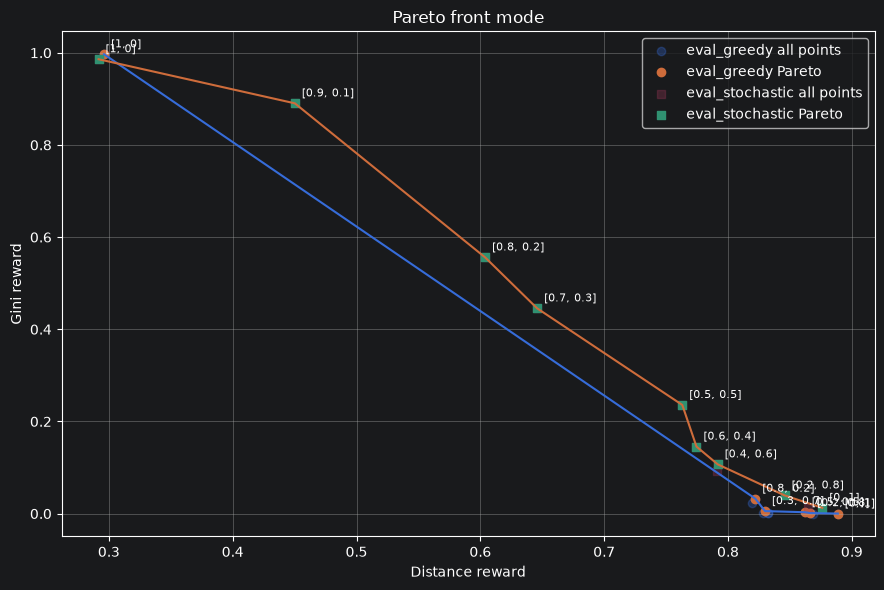

In [40]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_pareto_mode(
    ax,
    df,
    "eval_greedy",
    marker="o",
    show_dominated_points=True,
)

plot_pareto_mode(
    ax,
    df,
    "eval_stochastic",
    marker="s",
    show_dominated_points=True,
)

ax.set_xlabel("Distance reward")
ax.set_ylabel("Gini reward")
ax.grid(True)
ax.legend()

plt.title("Pareto front mode")

plt.tight_layout()
plt.show()

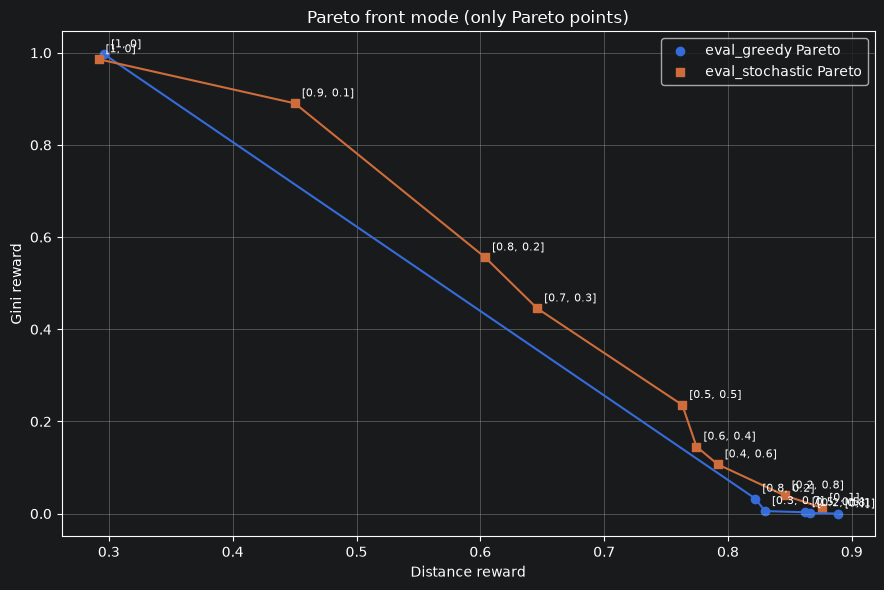

In [41]:
fig, ax = plt.subplots(figsize=(9, 6))

plot_pareto_mode(
    ax,
    df,
    "eval_greedy",
    marker="o",
    show_dominated_points=False,
)

plot_pareto_mode(
    ax,
    df,
    "eval_stochastic",
    marker="s",
    show_dominated_points=False,
)

ax.set_xlabel("Distance reward")
ax.set_ylabel("Gini reward")
ax.grid(True)
ax.legend()

plt.title("Pareto front mode (only Pareto points)")

plt.tight_layout()
plt.show()